In [1]:
import pandas as pd 
import numpy as np
import matplotlib. pyplot as plt 
data= pd.read_csv("netflix_titles.csv")
print(data)

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

In [2]:
print(data.head())
print(data.tail())
print(data.shape)
print(data.info())
print(data.size)
print(data.describe())
print(data.isna())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
print(data.isna().sum())
print(data.duplicated().sum())
data["date_added"]=pd.to_datetime(data["date_added"],format="mixed", errors="coerce")
print(data["date_added"].dtype)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
0
datetime64[us]


In [4]:
print(data.dtypes)

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object


In [5]:
data["year_added"]=data["date_added"].dt.year
print(data[["date_added","year_added"]].head())
data["month_added"]=data["date_added"].dt.month
print(data[["date_added","month_added"]].head())



  date_added  year_added
0 2021-09-25      2021.0
1 2021-09-24      2021.0
2 2021-09-24      2021.0
3 2021-09-24      2021.0
4 2021-09-24      2021.0
  date_added  month_added
0 2021-09-25          9.0
1 2021-09-24          9.0
2 2021-09-24          9.0
3 2021-09-24          9.0
4 2021-09-24          9.0


In [6]:
print(data["year_added"].value_counts().sort_index())
print(data["month_added"].value_counts().sort_index())

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64
month_added
1.0     738
2.0     563
3.0     742
4.0     764
5.0     632
6.0     728
7.0     827
8.0     755
9.0     770
10.0    760
11.0    705
12.0    813
Name: count, dtype: int64


In [7]:
print(data.groupby("type")["year_added"].value_counts())
print(data[data["year_added"] == 2019]["type"].value_counts())

type     year_added
Movie    2019.0        1424
         2020.0        1284
         2018.0        1237
         2021.0         993
         2017.0         839
         2016.0         253
         2015.0          56
         2014.0          19
         2011.0          13
         2013.0           6
         2012.0           3
         2009.0           2
         2008.0           1
         2010.0           1
TV Show  2020.0         595
         2019.0         592
         2021.0         505
         2018.0         412
         2017.0         349
         2016.0         176
         2015.0          26
         2014.0           5
         2013.0           5
         2008.0           1
Name: count, dtype: int64
type
Movie      1424
TV Show     592
Name: count, dtype: int64


In [8]:
print(data["type"].value_counts())
print(data[data["year_added"]==2019]["type"].value_counts().sum())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
2016


In [9]:
movie_percentage2019=1424/2016*100
print(movie_percentage2019)
show_percentage2019=592 / 2016 * 100
print(show_percentage2019)

70.63492063492063
29.365079365079367


In [10]:
print(data["year_added"].value_counts().idxmin())
print(data["country"].value_counts().idxmax())

2010.0
United States


In [11]:
print(data["type"].value_counts())
print(len(data))
print(data["rating"].value_counts().idxmax())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
8807
TV-MA


In [12]:
print(data[data["year_added"]>2019]["year_added"].value_counts().idxmax())
print(data[data["year_added"]==2020]["type"].value_counts())
print(data.head())

2020.0
type
Movie      1284
TV Show     595
Name: count, dtype: int64
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA 

In [13]:
print(data[data["type"]=="TV Show"]["year_added"].value_counts().idxmax())
print(data[data["year_added"]==2021]["type"].value_counts())
print(data[data["type"]=="Movie"]["year_added"].value_counts().idxmax())

2020.0
type
Movie      993
TV Show    505
Name: count, dtype: int64
2019.0


In [14]:
dset_percenatge=6131 / 8807 * 100
print(dset_percenatge)

69.61507891449983


In [15]:
print(data["rating"].value_counts().head(5))
print(data["country"].value_counts().head(5))
print(data["listed_in"].value_counts().head())

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64


In [16]:
print(data[data["year_added"]==2019]["listed_in"].value_counts().head(10))

listed_in
Documentaries                                       80
Dramas, Independent Movies, International Movies    76
Stand-Up Comedy                                     65
Dramas, International Movies                        62
Children & Family Movies, Comedies                  55
Comedies, Dramas, International Movies              55
Comedies, International Movies                      50
Dramas, International Movies, Romantic Movies       41
Documentaries, International Movies                 40
Children & Family Movies                            40
Name: count, dtype: int64


In [17]:
print(data[data["country"]=="India"]["type"].value_counts())
print(data[data["country"]=="India"]["year_added"].value_counts().idxmax())
print(data[(data["country"]=="India")&(data["year_added"]== 2018)]["type"].value_counts())

type
Movie      893
TV Show     79
Name: count, dtype: int64
2018.0
type
Movie      316
TV Show     17
Name: count, dtype: int64


In [3]:
print(79 / 972 * 100)
print(893 / 972 * 100)

8.127572016460906
91.8724279835391


In [4]:
genres=data["listed_in"].str.split(", ").explode()
print(genres.value_counts().head(10))

NameError: name 'data' is not defined

In [ ]:
india_genre=data[data["country"]=="India"]["listed_in"].str.split(", ").explode()
print(india_genre.value_counts().head(10))

listed_in
International Movies      817
Dramas                    620
Comedies                  308
Independent Movies        150
Action & Adventure        127
Romantic Movies           118
Thrillers                  88
Music & Musicals           88
International TV Shows     65
Horror Movies              32
Name: count, dtype: int64


In [ ]:
print(data[data["country"]=="India"]["type"].value_counts())
india_percentage_movie=893/972*100
india_percentage_show=79/972*100
print(india_percentage_movie,india_percentage_show)
print(data[data["country"]=="India"]["year_added"].value_counts().idxmax())
print(data[(data["country"]=="India")& (data["year_added"]==2018)]["type"].value_counts())
print(data[(data["country"]=="India")&(data["type"]=="Movie")]["rating"].value_counts())
print(data[(data["country"]=="India")&(data["type"]=="TV Show")]["rating"].value_counts())
print(893/79)

type
Movie      893
TV Show     79
Name: count, dtype: int64
91.8724279835391 8.127572016460906
2018.0
type
Movie      316
TV Show     17
Name: count, dtype: int64
rating
TV-14       526
TV-MA       215
TV-PG       124
TV-Y7        10
TV-G          6
PG-13         4
NR            4
PG            2
R             1
TV-Y7-FV      1
Name: count, dtype: int64
rating
TV-MA    33
TV-14    24
TV-PG    10
TV-Y      5
TV-Y7     4
TV-G      3
Name: count, dtype: int64
11.30379746835443


In [ ]:
print(genres.value_counts().idxmax())

International Movies


In [ ]:
print(data.groupby(["year_added","type"]).size())
print(data["director"].value_counts().head(10))
actor=data["cast"].str.split(", ").explode()
print(actor.value_counts().head(10))
print(data.groupby("type")["release_year"].mean())

year_added  type   
2008.0      Movie         1
            TV Show       1
2009.0      Movie         2
2010.0      Movie         1
2011.0      Movie        13
2012.0      Movie         3
2013.0      Movie         6
            TV Show       5
2014.0      Movie        19
            TV Show       5
2015.0      Movie        56
            TV Show      26
2016.0      Movie       253
            TV Show     176
2017.0      Movie       839
            TV Show     349
2018.0      Movie      1237
            TV Show     412
2019.0      Movie      1424
            TV Show     592
2020.0      Movie      1284
            TV Show     595
2021.0      Movie       993
            TV Show     505
dtype: int64
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg         

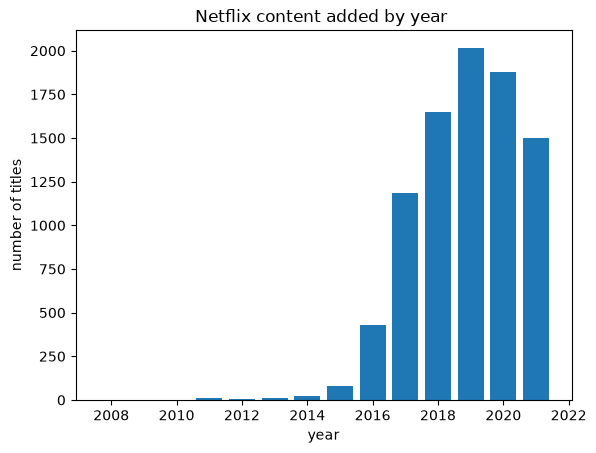

In [ ]:
year_added = data["year_added"].value_counts().sort_index()
plt.bar(year_added.index,year_added.values)
plt.title("Netflix content added by year ")
plt.xlabel("year")
plt.ylabel("number of titles")
plt.show()

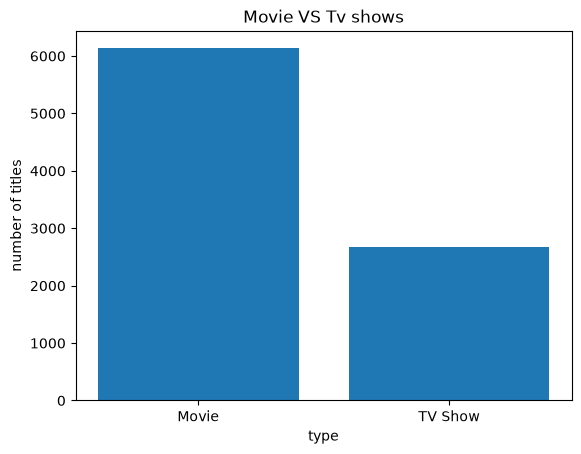

In [ ]:
type_count=data["type"].value_counts()
plt.bar(type_count.index,type_count.values)
plt.title("Movie VS Tv shows")
plt.xlabel("type")
plt.ylabel("number of titles")
plt.show()

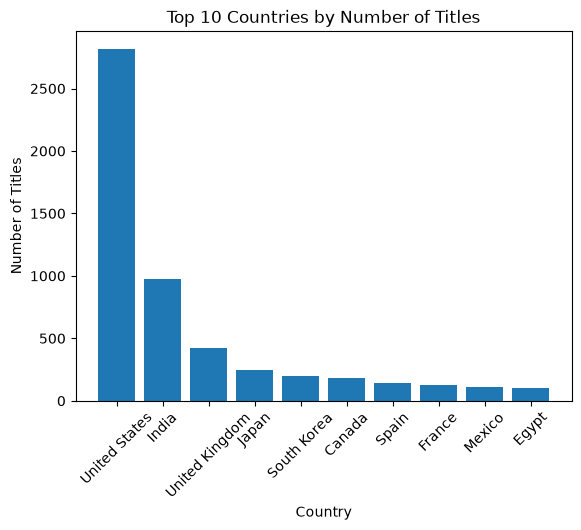

In [ ]:
country_count = data["country"].value_counts().head(10)

plt.bar(country_count.index, country_count.values)

plt.title("Top 10 Countries by Number of Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

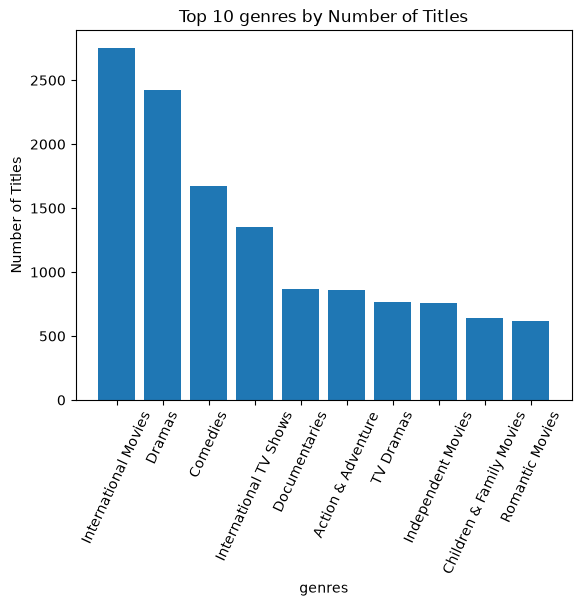

In [ ]:
genres_count=genres.value_counts().head(10)

plt.bar(genres_count.index,genres_count.values)

plt.title("Top 10 genres by Number of Titles")
plt.xlabel("genres")
plt.ylabel("Number of Titles")
plt.xticks(rotation=65)
plt.show()


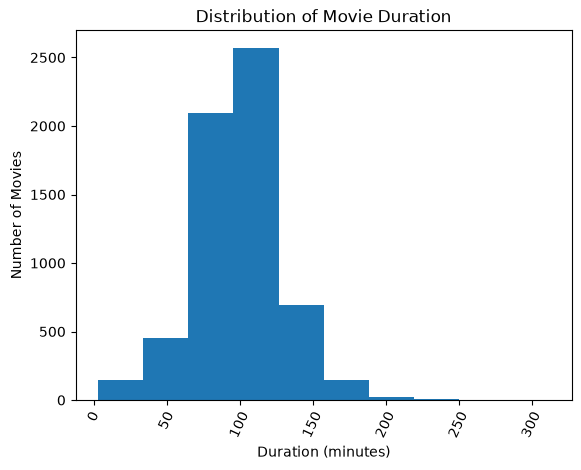

In [ ]:
movie_duration=data[data["type"]=="Movie"]["duration"].str.replace(" min","").astype(float)

plt.hist(movie_duration)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.xticks(rotation=65)

plt.show()


0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: str


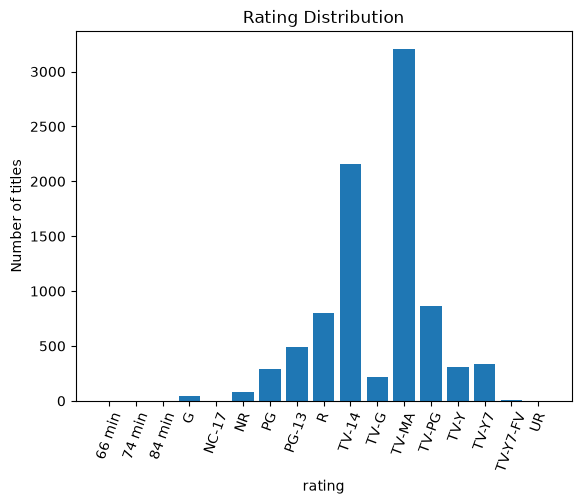

In [ ]:
print(data["rating"])
rating_count=data["rating"].value_counts().sort_index()
plt.bar(rating_count.index,rating_count.values)

plt.title("Rating Distribution")
plt.xlabel("rating")
plt.ylabel("Number of titles")
plt.xticks(rotation=70)
plt.show()

In [ ]:
data.to_csv("netflix_clean.csv", index=False)


show_id
s4230    1
s4231    1
s4232    1
s4233    1
s4234    1
        ..
s4305    1
s4306    1
s4307    1
s4308    1
s4309    1
Name: count, Length: 80, dtype: int64
